# Dataset V3 Hotspot Detection

This notebook uses the final Dataset V3 XGBoost model to predict Land Surface Temperature across sampled locations and identify urban heat-stress hotspots.

Latitude and Longitude are used for mapping and zone grouping only. They are not used as prediction features.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

# Load model-ready Dataset V3
df_hotspot_v3 = pd.read_csv("../data/processed/model_ready_uhi_v3.csv")

# Load final Dataset V3 XGBoost model
final_xgb_v3 = joblib.load(
    "../outputs/models/xgboost_v3_landcover_model.pkl"
)

# Load the exact model feature order
feature_order_v3 = pd.read_csv(
    "../outputs/models/xgboost_v3_feature_order.csv"
)["Feature"].tolist()

print("Dataset V3 model-ready file loaded")
print("Dataset shape:", df_hotspot_v3.shape)

print("\nFinal XGBoost V3 model loaded")
print("Number of model features:", len(feature_order_v3))
print("\nFeature order:")
print(feature_order_v3)

Dataset V3 model-ready file loaded
Dataset shape: (9893, 14)

Final XGBoost V3 model loaded
Number of model features: 11

Feature order:
['NDVI', 'NDBI', 'Elevation', 'Population', 'LandCover_Bare_sparse_vegetation', 'LandCover_Built-up land', 'LandCover_Cropland', 'LandCover_Grassland', 'LandCover_Permanent_water_bodies', 'LandCover_Shrubland', 'LandCover_Tree cover']


In [2]:
# Select model features in the exact saved order
X_hotspot_v3 = df_hotspot_v3[feature_order_v3]

# Predict LST using the final V3 XGBoost model
df_hotspot_v3["Predicted_LST"] = final_xgb_v3.predict(X_hotspot_v3)

# Residual is useful for checking model prediction difference
df_hotspot_v3["Residual"] = (
    df_hotspot_v3["LST"] - df_hotspot_v3["Predicted_LST"]
)

print("Predictions created successfully")

print("\nObserved vs predicted LST summary:")
print(
    df_hotspot_v3[["LST", "Predicted_LST", "Residual"]]
    .describe()
    .round(2)
)

Predictions created successfully

Observed vs predicted LST summary:
           LST  Predicted_LST  Residual
count  9893.00        9893.00   9893.00
mean     43.46          43.46      0.00
std       3.23           2.66      1.44
min      27.76          27.74     -6.75
25%      41.24          41.64     -0.89
50%      43.61          43.71      0.03
75%      45.97          45.63      0.93
max      51.96          49.93      5.06


In [3]:
# Create heat-stress categories from observed LST quartiles
q1 = df_hotspot_v3["LST"].quantile(0.25)
q2 = df_hotspot_v3["LST"].quantile(0.50)
q3 = df_hotspot_v3["LST"].quantile(0.75)

heat_bins = [-np.inf, q1, q2, q3, np.inf]
heat_labels = ["Low", "Moderate", "High", "Very High"]

df_hotspot_v3["Heat_Category"] = pd.cut(
    df_hotspot_v3["LST"],
    bins=heat_bins,
    labels=heat_labels,
    include_lowest=True
)

print("Heat category thresholds:")
print("Low: <=", round(q1, 2), "°C")
print("Moderate:", round(q1, 2), "to", round(q2, 2), "°C")
print("High:", round(q2, 2), "to", round(q3, 2), "°C")
print("Very High: >", round(q3, 2), "°C")

print("\nHeat category counts:")
print(df_hotspot_v3["Heat_Category"].value_counts().sort_index())

Heat category thresholds:
Low: <= 41.24 °C
Moderate: 41.24 to 43.61 °C
High: 43.61 to 45.97 °C
Very High: > 45.97 °C

Heat category counts:
Heat_Category
Low          2474
Moderate     2473
High         2474
Very High    2472
Name: count, dtype: int64


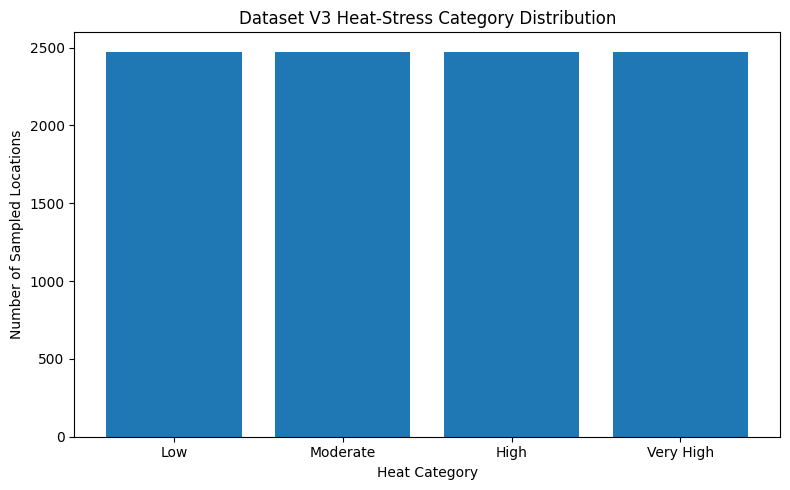

In [4]:
heat_category_counts = (
    df_hotspot_v3["Heat_Category"]
    .value_counts()
    .reindex(heat_labels)
)

plt.figure(figsize=(8, 5))
plt.bar(
    heat_category_counts.index.astype(str),
    heat_category_counts.values
)
plt.title("Dataset V3 Heat-Stress Category Distribution")
plt.xlabel("Heat Category")
plt.ylabel("Number of Sampled Locations")
plt.tight_layout()
plt.show()

In [6]:
# Hotspots are the locations in the Very High observed LST category
hotspots_v3 = df_hotspot_v3[
    df_hotspot_v3["Heat_Category"] == "Very High"
].copy()

# Reconstruct the readable LandCover class from one-hot encoded columns
landcover_feature_columns = [
    col for col in df_hotspot_v3.columns
    if col.startswith("LandCover_")
]

df_hotspot_v3["LandCover_Class"] = (
    df_hotspot_v3[landcover_feature_columns]
    .idxmax(axis=1)
    .str.replace("LandCover_", "", regex=False)
)

hotspots_v3["LandCover_Class"] = (
    hotspots_v3[landcover_feature_columns]
    .idxmax(axis=1)
    .str.replace("LandCover_", "", regex=False)
)

print("Total sampled locations:", len(df_hotspot_v3))
print("Hotspot locations:", len(hotspots_v3))
print(
    "Hotspot percentage:",
    round(len(hotspots_v3) / len(df_hotspot_v3) * 100, 2),
    "%"
)

display(
    hotspots_v3[
        [
            "Latitude",
            "Longitude",
            "LST",
            "Predicted_LST",
            "NDVI",
            "NDBI",
            "Elevation",
            "Population",
            "LandCover_Class"
        ]
    ].head()
)

Total sampled locations: 9893
Hotspot locations: 2472
Hotspot percentage: 24.99 %


,Latitude,Longitude,LST,Predicted_LST,NDVI,NDBI,Elevation,Population,LandCover_Class
4,19.867709,75.486062,48.502735,47.015202,0.165262,0.133151,586,31.397209,Grassland
6,19.935852,75.301694,46.896266,46.437984,0.140019,0.057766,648,5.117677,Grassland
9,19.925993,75.308438,47.634558,44.191982,0.233355,0.058598,640,8.145835,Shrubland
12,20.001870,75.419442,46.197281,46.135544,0.195049,0.148148,760,2.585382,Cropland
21,19.945237,75.496180,47.121855,45.934628,0.154745,0.080233,746,2.097851,Cropland


In [7]:
# Group points into approximately 0.02-degree spatial zones
grid_size = 0.02

df_hotspot_v3["Lat_Block"] = np.floor(
    (df_hotspot_v3["Latitude"] - df_hotspot_v3["Latitude"].min()) / grid_size
).astype(int)

df_hotspot_v3["Lon_Block"] = np.floor(
    (df_hotspot_v3["Longitude"] - df_hotspot_v3["Longitude"].min()) / grid_size
).astype(int)

df_hotspot_v3["Zone_ID"] = (
    df_hotspot_v3["Lat_Block"].astype(str)
    + "_"
    + df_hotspot_v3["Lon_Block"].astype(str)
)

print("Number of zones:", df_hotspot_v3["Zone_ID"].nunique())

Number of zones: 334


In [8]:
zone_summary_v3 = (
    df_hotspot_v3.groupby("Zone_ID")
    .agg(
        Mean_LST=("LST", "mean"),
        Mean_Predicted_LST=("Predicted_LST", "mean"),
        Max_LST=("LST", "max"),
        Mean_NDVI=("NDVI", "mean"),
        Mean_NDBI=("NDBI", "mean"),
        Mean_Population=("Population", "mean"),
        Point_Count=("LST", "count"),
        Very_High_Hotspot_Count=(
            "Heat_Category",
            lambda x: (x == "Very High").sum()
        ),
        Zone_Latitude=("Latitude", "mean"),
        Zone_Longitude=("Longitude", "mean")
    )
    .reset_index()
)

zone_summary_v3["Hotspot_Percentage"] = (
    zone_summary_v3["Very_High_Hotspot_Count"]
    / zone_summary_v3["Point_Count"]
    * 100
).round(2)

zone_summary_v3 = zone_summary_v3.sort_values(
    by=["Mean_LST", "Hotspot_Percentage"],
    ascending=False
).reset_index(drop=True)

print("Top 10 hottest zones:")
display(zone_summary_v3.head(10))

Top 10 hottest zones:


,Zone_ID,Mean_LST,Mean_Predicted_LST,Max_LST,Mean_NDVI,Mean_NDBI,Mean_Population,Point_Count,Very_High_Hotspot_Count,Zone_Latitude,Zone_Longitude,Hotspot_Percentage
0,4_22,48.158655,46.650745,50.447589,0.222963,0.092786,2.584655,6,5,19.810988,75.584888,83.33
1,4_21,47.612930,46.940758,49.481998,0.188821,0.103167,2.618992,29,27,19.813187,75.571824,93.10
2,5_20,47.552526,45.852337,50.034008,0.202059,0.047122,2.840524,38,35,19.832173,75.553111,92.11
3,3_21,47.517681,46.191303,50.257889,0.204836,0.075184,2.340091,18,14,19.799522,75.569608,77.78
4,4_20,47.516779,46.277409,50.608236,0.197170,0.058913,2.684914,36,31,19.812505,75.552733,86.11
5,0_15,47.465366,47.156380,47.465366,0.127480,0.101048,2.911846,1,1,19.741849,75.445563,100.00
6,6_20,47.432254,45.721588,50.309159,0.194545,0.076918,5.377040,32,29,19.853783,75.551956,90.62
7,5_22,47.203155,46.952824,48.760796,0.183787,0.101800,2.367950,7,5,19.828271,75.583563,71.43
8,7_15,47.186326,46.210579,50.283524,0.178169,0.071149,6.307922,29,23,19.874958,75.452508,79.31
9,5_21,47.054278,46.454086,50.647543,0.166336,0.113842,2.370612,24,18,19.832870,75.572410,75.00


In [9]:
# Top 10 hottest zones become priority hotspot zones
zone_summary_v3["Hotspot_Priority"] = "Standard"

top_zone_count = min(10, len(zone_summary_v3))

zone_summary_v3.loc[
    zone_summary_v3.index < top_zone_count,
    "Hotspot_Priority"
] = "High Priority"

print("Priority-zone counts:")
print(zone_summary_v3["Hotspot_Priority"].value_counts())

display(
    zone_summary_v3[
        [
            "Zone_ID",
            "Mean_LST",
            "Max_LST",
            "Mean_NDBI",
            "Mean_NDVI",
            "Mean_Population",
            "Hotspot_Percentage",
            "Hotspot_Priority"
        ]
    ].head(10)
)

Priority-zone counts:
Hotspot_Priority
Standard         324
High Priority     10
Name: count, dtype: int64


,Zone_ID,Mean_LST,Max_LST,Mean_NDBI,Mean_NDVI,Mean_Population,Hotspot_Percentage,Hotspot_Priority
0,4_22,48.158655,50.447589,0.092786,0.222963,2.584655,83.33,High Priority
1,4_21,47.612930,49.481998,0.103167,0.188821,2.618992,93.10,High Priority
2,5_20,47.552526,50.034008,0.047122,0.202059,2.840524,92.11,High Priority
3,3_21,47.517681,50.257889,0.075184,0.204836,2.340091,77.78,High Priority
4,4_20,47.516779,50.608236,0.058913,0.197170,2.684914,86.11,High Priority
5,0_15,47.465366,47.465366,0.101048,0.127480,2.911846,100.00,High Priority
6,6_20,47.432254,50.309159,0.076918,0.194545,5.377040,90.62,High Priority
7,5_22,47.203155,48.760796,0.101800,0.183787,2.367950,71.43,High Priority
8,7_15,47.186326,50.283524,0.071149,0.178169,6.307922,79.31,High Priority
9,5_21,47.054278,50.647543,0.113842,0.166336,2.370612,75.00,High Priority


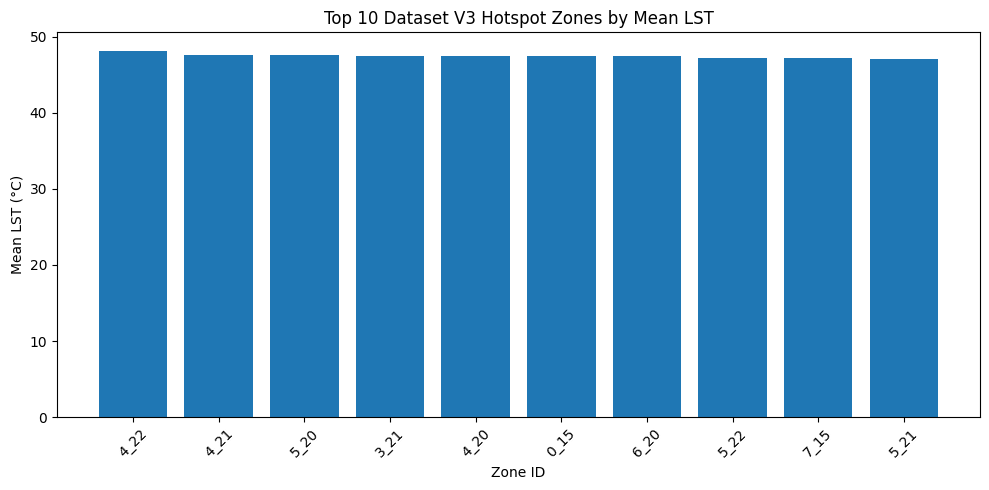

In [10]:
top_zones_plot = zone_summary_v3.head(10).copy()

plt.figure(figsize=(10, 5))
plt.bar(
    top_zones_plot["Zone_ID"],
    top_zones_plot["Mean_LST"]
)
plt.title("Top 10 Dataset V3 Hotspot Zones by Mean LST")
plt.xlabel("Zone ID")
plt.ylabel("Mean LST (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

df_hotspot_v3.to_csv(
    "../data/processed/hotspot_predictions_v3.csv",
    index=False
)

hotspots_v3.to_csv(
    "../data/processed/hotspot_points_v3.csv",
    index=False
)

zone_summary_v3.to_csv(
    "../outputs/reports/hotspot_zone_priority_v3.csv",
    index=False
)

print("Saved:")
print("data/processed/hotspot_predictions_v3.csv")
print("data/processed/hotspot_points_v3.csv")
print("outputs/reports/hotspot_zone_priority_v3.csv")

Saved:
data/processed/hotspot_predictions_v3.csv
data/processed/hotspot_points_v3.csv
outputs/reports/hotspot_zone_priority_v3.csv


## Dataset V3 Hotspot Detection Conclusion

Dataset V3 hotspot detection was performed using observed Land Surface Temperature values and predictions from the final XGBoost model.

Heat-stress categories were created using LST quartiles. Locations in the Very High category were identified as hotspot points.

Sampled locations were grouped into spatial zones using a 0.02-degree grid. Zones were ranked using mean LST and hotspot concentration, and the top 10 zones were marked as High Priority.

Latitude and Longitude were used only for zone grouping and mapping. They were not used as model prediction features.